# Week 02 - Lesson 05: Multi-Agent Systems: Hierarchical

## Overview

This notebook demonstrates **Hierarchical Multi-Agent System Architecture**. We'll extend the single supervisor approach by adding mid-level supervisors to manage groups of workers, enabling us to tackle more complex or larger-scale tasks.

### Learning Objectives
By the end of this notebook, you will:

- Build a complete hierarchical agent system
- Understand how hierarchical routing differs from a single supervisor
- Create worker agents and mid-level supervisors
- Build a complete hierarchical research assistant system

### Architecture

- **Top-level Supervisor**: Oversees the system and routes requests to mid-level teams
- **Mid-level Supervisors**: Manage subgraphs (specific domains or subtasks)
- **Worker Agents**: Execute specialized actions using one or more tools

### Why Hierarchical?

In the previous example `agent supervisor`, we used a single node to route tasks to workers. However, when tasks grow in complexity or when the number of workers becomes too large, this single supervisor can become a bottleneck.

By structuring the system hierarchically, we distribute responsibility: supervisors manage their own teams, and the top-level supervisor coordinates among them. This structure makes the system more scalable and easier to reason about.


In [3]:
from IPython.display import IFrame

IFrame("https://drive.google.com/file/d/1SVz2F6abyqwG755-CHJlK7DDo7jA7vsj/preview", 
       width=440, 
       height=350)



## 1. Environment Setup and Dependencies

In [1]:
# Install required dependencies
%pip install -U --quiet langchain langgraph langchain_community

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup and imports
import os
from typing import Literal

from langchain_core.language_models.chat_models import BaseChatModel

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from typing_extensions import TypedDict

In [15]:
# Set OpenAI API Key
import os
os.environ["OPENAI_API_KEY"] = "sk-your-openai-api-key"

In [4]:
# Create Tools - Simple tools that returns an acknowledgment message
# In a real scenario, these tools would be more complex and use external APIs
@tool
def analyze_customer_issue(issue_description: str) -> str:
    """Analyze customer issue and categorize it."""
    return f"Issue analyzed: {issue_description[:50]}... Category: Technical, Priority: High, Estimated resolution: 2 hours"

@tool
def check_customer_history(customer_id: str) -> str:
    """Check customer's previous issues and account status."""
    return f"Customer {customer_id} history: 3 previous tickets, VIP status, last issue resolved 5 days ago"

@tool
def generate_solution(issue_category: str) -> str:
    """Generate solution based on issue category."""
    return f"Solution generated for {issue_category}: Step-by-step troubleshooting guide with escalation path"

@tool
def escalate_to_human(issue_complexity: str) -> str:
    """Escalate complex issues to human agent."""
    return f"Issue escalated to human agent due to: {issue_complexity}. Ticket created with priority level."

print("✅ Simple tools created!")


✅ Simple tools created!


In [5]:
class State(MessagesState):
    next: str

# Define a supervisor node that routes messages to the workers
def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

In [6]:
from langgraph.prebuilt import create_react_agent

# Define LLM
llm = ChatOpenAI(model="gpt-4o")

# Define issue analyzer agent
issue_analyzer_agent = create_react_agent(
    llm,
    tools=[analyze_customer_issue],
)

def issue_analyzer_node(state: State) -> Command[Literal["analysis_supervisor"]]:
    """Analyze customer issues."""
    response = issue_analyzer_agent.invoke(state)
    return Command(update={"messages": [HumanMessage(content=response["messages"][-1].content, name="issue_analyzer")]}, goto="analysis_supervisor")

# Define history checker agent
history_checker_agent = create_react_agent(
    llm,
    tools=[check_customer_history],
)

def history_checker_node(state: State) -> Command[Literal["analysis_supervisor"]]:
    """Check customer history."""
    response = history_checker_agent.invoke(state)
    return Command(update={"messages": [HumanMessage(content=response["messages"][-1].content, name="history_checker")]}, goto="analysis_supervisor")

# Define analysis supervisor node
analysis_supervisor_node = make_supervisor_node(llm, ["issue_analyzer", "history_checker"])

# Build Analysis Team Graph
analysis_builder = StateGraph(State)
analysis_builder.add_node("analysis_supervisor", analysis_supervisor_node)
analysis_builder.add_node("issue_analyzer", issue_analyzer_node)
analysis_builder.add_node("history_checker", history_checker_node)
analysis_builder.add_edge(START, "analysis_supervisor")
analysis_graph = analysis_builder.compile()

print("✅ Analysis team created!")


✅ Analysis team created!


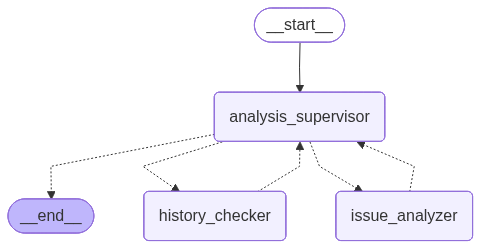

In [7]:
from IPython.display import Image
Image(analysis_graph.get_graph().draw_mermaid_png())

In [8]:
# Define solution generator agent
solution_generator_agent = create_react_agent(
    llm,
    tools=[generate_solution],
)

def solution_generator_node(state: State) -> Command[Literal["resolution_supervisor"]]:
    """Generate solutions for customer issues."""
    response = solution_generator_agent.invoke(state)
    return Command(update={"messages": [HumanMessage(content=response["messages"][-1].content, name="solution_generator")]}, goto="resolution_supervisor")

# Define escalation handler agent
escalation_handler_agent = create_react_agent(
    llm,
    tools=[escalate_to_human],
)

def escalation_handler_node(state: State) -> Command[Literal["resolution_supervisor"]]: 
    """Handle escalation decisions."""
    response = escalation_handler_agent.invoke(state)
    return Command(update={"messages": [HumanMessage(content=response["messages"][-1].content, name="escalation_handler")]}, goto="resolution_supervisor")

# Define resolution supervisor node
resolution_supervisor_node = make_supervisor_node(llm, ["solution_generator", "escalation_handler"])

# Build Resolution Team Graph
resolution_builder = StateGraph(State)
resolution_builder.add_node("resolution_supervisor", resolution_supervisor_node)
resolution_builder.add_node("solution_generator", solution_generator_node)
resolution_builder.add_node("escalation_handler", escalation_handler_node)
resolution_builder.add_edge(START, "resolution_supervisor")
resolution_graph = resolution_builder.compile()

print("✅ Resolution team created!")


✅ Resolution team created!


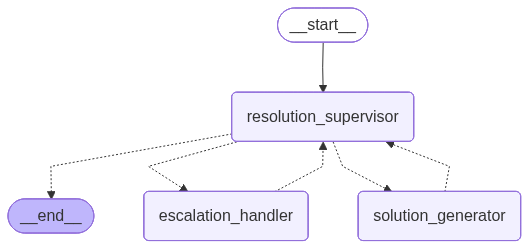

In [9]:
from IPython.display import Image
Image(resolution_graph.get_graph().draw_mermaid_png())

In [10]:
# Now we can build the top-level supervisor that will route messages to the analysis and resolution teams
top_level_supervisor = make_supervisor_node(llm, ["analysis_team", "resolution_team"])

def call_analysis_team(state: MessagesState) -> Command[Literal["top_level_supervisor"]]:
    """Call the analysis team."""
    response = analysis_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="analysis_team"
                )
            ]
        },
        goto="top_level_supervisor",
    )

def call_resolution_team(state: MessagesState) -> Command[Literal["top_level_supervisor"]]:
    """Call the resolution team."""
    response = resolution_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="resolution_team"
                )
            ]
        },
        goto="top_level_supervisor",
    )

# Build the top-level graph
super_builder = StateGraph(MessagesState)
super_builder.add_node("top_level_supervisor", top_level_supervisor)
super_builder.add_node("analysis_team", call_analysis_team)
super_builder.add_node("resolution_team", call_resolution_team)
super_builder.add_edge(START, "top_level_supervisor")
super_graph = super_builder.compile()

print("✅ Hierarchical agent system created!")


✅ Hierarchical agent system created!


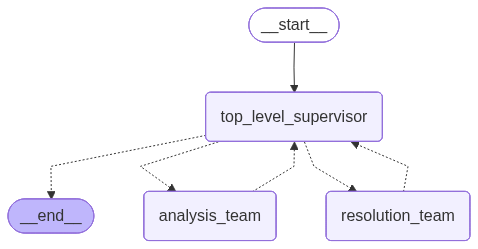

In [11]:
from IPython.display import Image
Image(super_graph.get_graph().draw_mermaid_png())

In [14]:
# Now we can test the hierarchical agent system
for s in super_graph.stream(
    {
        "messages": [
            ("user", "Customer ID 12345 reports login issues with error message 'Invalid credentials'.")
        ],
    },
    {"recursion_limit": 150},
):
    print(s)
    print("---")

{'top_level_supervisor': {'next': 'analysis_team'}}
---
{'analysis_team': {'messages': [HumanMessage(content='The issue regarding the login problem for Customer ID 12345 has been categorized as a "Technical" issue with high priority. The estimated time for resolution is approximately 2 hours. Given their VIP status, we may consider offering a password reset and providing a direct support line for faster assistance.', additional_kwargs={}, response_metadata={}, name='analysis_team', id='ef26627e-8078-428a-be16-96a27ae3834b')]}}
---
{'top_level_supervisor': {'next': 'resolution_team'}}
---
{'resolution_team': {'messages': [HumanMessage(content='The login issue for VIP Customer ID 12345 has been escalated to a human agent due to its technical nature and high priority. A support ticket has been created, prioritizing immediate attention to the problem. The technical team will handle the database or server-side troubleshooting as necessary. Additionally, customer support enhancements for VIP

---

## Key Takeaways

### What We’ve Accomplished

* Built and executed a **hierarchical agent system** with a top-level supervisor and specialized teams.
* Demonstrated how requests can be routed step by step through different layers.

### How the System Behaved

1. **Top-level Supervisor → Analysis Team**
   
   The supervisor first routed the user’s request to the **Analysis Team**.

   - The analysis identified the issue as a **technical problem** with **high priority** because the customer is VIP.
   - An **estimated resolution time** of 2 hours was provided.

2. **Top-level Supervisor → Resolution Team**
   
   After analysis, the supervisor escalated the case to the **Resolution Team**.

   * The resolution agent determined that, given the **VIP status and high priority**, the issue should be escalated to a **human agent**.
   * This ensures that critical customer cases receive direct attention.

3. **Top-level Supervisor → End**
   
   Finally, the supervisor closed the workflow by signaling `__end__`, meaning the system had successfully completed the task routing.